Gabriela Nirmal, Udita Shah, Praveen Sinha

In [1]:
# imports

import numpy as np
import pandas as pd

In [2]:
# load the PCOS dataset
df = pd.read_csv("data/PCOS_data.csv")
df.head()


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [3]:
# CLEAN DATA   

# renaming some columns
df = df.rename(columns={
    '  I   beta-HCG(mIU/mL)': 'beta-HCG(mIU/mL) 1',
    'II    beta-HCG(mIU/mL)': 'beta-HCG(mIU/mL) 2',
    'Marraige Status (Yrs)': 'Marriage Status (Yrs)',
    ' Age (yrs)': 'Age (yrs)'
})

# drop empty column and S. No (same as patient file No)
df = df.drop(columns=['Unnamed: 44', 'Sl. No'])

# set patient file number to index
df = df.set_index('Patient File No.')

# fixing messed up values
df = df.replace('a', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')
df['beta-HCG(mIU/mL) 2'] = df['beta-HCG(mIU/mL) 2'].replace('1.99.', '1.99')

# impute null values, small dataset so dropping data isn't preferrable
df.fillna(df.median(numeric_only=True), inplace=True)

# confirm no null values
print(df.isnull().sum())



PCOS (Y/N)               0
Age (yrs)                0
Weight (Kg)              0
Height(Cm)               0
BMI                      0
Blood Group              0
Pulse rate(bpm)          0
RR (breaths/min)         0
Hb(g/dl)                 0
Cycle(R/I)               0
Cycle length(days)       0
Marriage Status (Yrs)    0
Pregnant(Y/N)            0
No. of abortions         0
beta-HCG(mIU/mL) 1       0
beta-HCG(mIU/mL) 2       0
FSH(mIU/mL)              0
LH(mIU/mL)               0
FSH/LH                   0
Hip(inch)                0
Waist(inch)              0
Waist:Hip Ratio          0
TSH (mIU/L)              0
AMH(ng/mL)               0
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          0
Reg.Exercise(Y/N)        0
BP _Systolic (mmHg)      0
BP _Diastolic (mmHg)     0
F

In [4]:
df.head()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
Patient File No.,,,,,,,,,,,,,,,,,,,,,
1,0,28,44.6,152.0,19.3,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
2,0,36,65.0,161.5,24.9,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
3,1,33,68.8,165.0,25.3,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
4,0,37,65.0,148.0,29.7,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
5,0,25,52.0,161.0,20.1,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [5]:
# Checking for anymore non-numerical data before scaling
for col in df.columns:
    for val in df[col]:
        try:
            float(val)
        except (ValueError, TypeError):
            print(f"Column: {col}, Value: {val}")

Model 1 Concept: MLP w/ attention based feature weighting

Predicts a diagnosis for PCOS while simultaneously discovering the most important features that help to diagnose

In [6]:
#adding random seeds

import random
import tensorflow as tf
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# SCALE DATA

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# separate features and target
x = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

# scale the features to be between 0 and 1
x_scaled = scaler.fit_transform(x)

# convert back to pandas df
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

x_scaled.describe()


,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,0.408239,0.371911,0.453136,0.449343,0.400317,0.873155,0.270333,0.422228,0.186691,0.411738,...,0.489834,0.515712,0.247689,0.802045,0.749216,0.278609,0.332070,0.625755,0.643821,0.470884
std,0.193250,0.143225,0.140315,0.153024,0.262973,0.064207,0.140719,0.137604,0.300650,0.124335,...,0.500359,0.500216,0.432070,0.057692,0.060588,0.192241,0.221844,0.148618,0.138285,0.120299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.285714,0.272727,0.348837,0.347170,0.285714,0.855072,0.166667,0.317460,0.000000,0.333333,...,0.000000,0.000000,0.000000,0.765625,0.673913,0.136364,0.150000,0.541667,0.541667,0.388889
50%,0.392857,0.363636,0.441860,0.445283,0.428571,0.855072,0.166667,0.396825,0.000000,0.416667,...,0.000000,1.000000,0.000000,0.765625,0.782609,0.227273,0.300000,0.625000,0.666667,0.472222
75%,0.535714,0.441558,0.534884,0.535849,0.571429,0.884058,0.333333,0.507937,0.666667,0.416667,...,1.000000,1.000000,0.000000,0.843750,0.782609,0.409091,0.500000,0.750000,0.750000,0.544444
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# test and train split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2)

x_train, y_train

(     Age (yrs)  Weight (Kg)  Height(Cm)        BMI  Blood Group  \
 244   0.678571     0.948052     0.637209  0.984906     0.571429   
 540   0.107143     0.662338     0.651163  0.667925     0.285714   
 417   0.428571     0.529870     0.581395  0.566038     0.000000   
 509   0.928571     0.298701     0.348837  0.415094     0.285714   
 353   0.357143     0.311688     0.627907  0.301887     0.285714   
 ..         ...          ...          ...       ...          ...   
 71    0.321429     0.389610     0.325581  0.543396     0.285714   
 106   0.285714     0.376623     0.534884  0.415094     0.571429   
 270   0.357143     0.312987     0.712558  0.271698     0.000000   
 435   0.357143     0.428571     0.767442  0.366038     0.571429   
 102   0.642857     0.432468     0.279070  0.626415     0.000000   
 
      Pulse rate(bpm)   RR (breaths/min)  Hb(g/dl)  Cycle(R/I)  \
 244          0.855072          0.166667  0.555556    0.000000   
 540          0.971014          0.333333  0.269841

In [9]:
# fit model
from keras import layers
from keras import Input, Model


# custom attention layer
class FeatureAttention(layers.Layer):
    def __init__(self, input_dim):
        super().__init__()
        self.attention_weights = self.add_weight(
            shape=(input_dim,),
            initializer='ones',
            trainable=True,
            name='attention_weights'
        )
    
    def call(self, x):
        weights = tf.nn.softmax(self.attention_weights)
        return x * weights

# build the model
input_dim = x_train.shape[1]

inputs = Input(shape=(input_dim,))
attended = FeatureAttention(input_dim)(inputs)
x = layers.Dense(64, activation='relu')(attended)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


2026-04-14 12:59:55.106278: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-14 12:59:55.106297: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-14 12:59:55.106302: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-04-14 12:59:55.106315: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-14 12:59:55.106324: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_attention               │ (None, 41)             │            41 │
│ (FeatureAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842 (18.91 KB)

 Trainable params: 4,842 (18.91 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# train

from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500


2026-04-14 12:59:55.437645: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5652 - loss: 0.6903 - val_accuracy: 0.6552 - val_loss: 0.6797
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6667 - loss: 0.6710 - val_accuracy: 0.6552 - val_loss: 0.6642
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.6552 - val_accuracy: 0.6552 - val_loss: 0.6525
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.6454 - val_accuracy: 0.6552 - val_loss: 0.6447
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6408 - val_accuracy: 0.6552 - val_loss: 0.6388
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.6332 - val_accuracy: 0.6552 - val_loss: 0.6335
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.6273 - val_accuracy: 0.6552 - val_loss: 0.6275
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.6195 - val_accuracy: 0.6552 - val_l

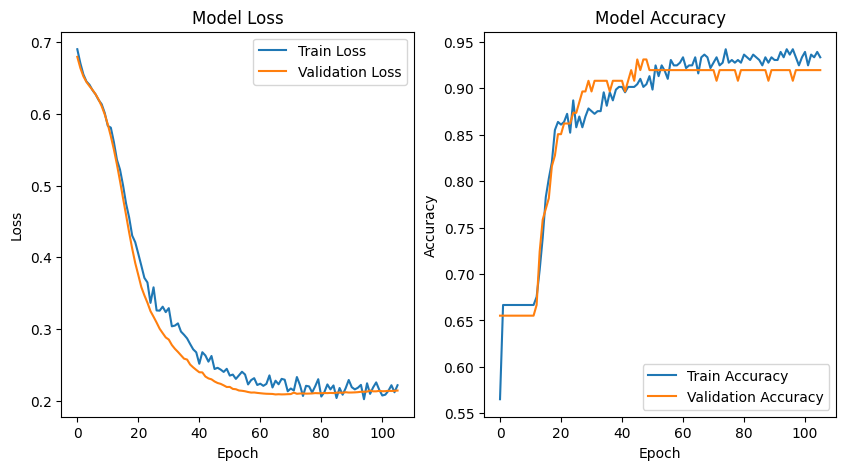

In [11]:
# plot loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [14]:
# evaluate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# get predictions
y_pred_proba = model.predict(x_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# loss and accuracy
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# f1, precision, recall
print(classification_report(y_test, y_pred, target_names=['No PCOS', 'PCOS']))

# AUC-ROC
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8991 - loss: 0.2475 
Test Accuracy: 0.8991
Test Loss: 0.2475
              precision    recall  f1-score   support

     No PCOS       0.89      0.97      0.93        77
        PCOS       0.92      0.72      0.81        32

    accuracy                           0.90       109
   macro avg       0.91      0.85      0.87       109
weighted avg       0.90      0.90      0.90       109

AUC-ROC: 0.9509
Confusion Matrix:
[[75  2]
 [ 9 23]]


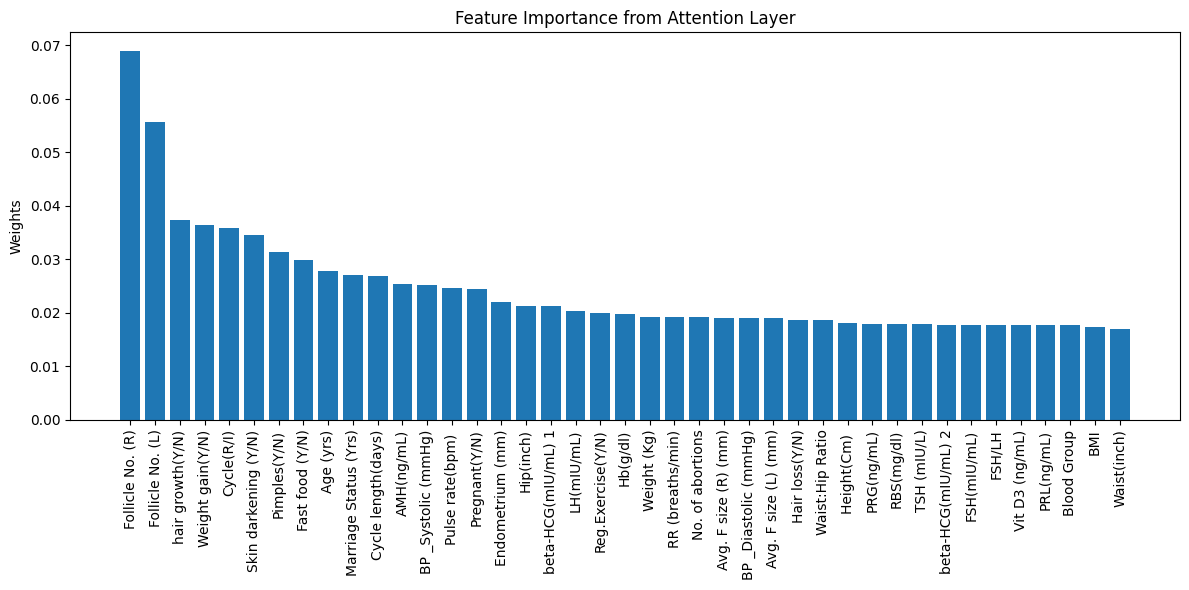

In [13]:
import numpy as np

# get the attention weights
attention_layer = model.layers[1]
weights = tf.nn.softmax(attention_layer.attention_weights).numpy()

# plot
plt.figure(figsize=(12, 6))
indices = np.argsort(weights)[::-1]
plt.bar(range(len(weights)), weights[indices])
plt.ylabel("Weights")
plt.xticks(range(len(weights)), x_train.columns[indices], rotation=90)
plt.title('Feature Importance from Attention Layer')
plt.tight_layout()
plt.show()